# Playground Hein

## Setup

In [8]:
import os
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
from networkx.algorithms.community import louvain_communities
from scipy.spatial import ConvexHull

from dotenv import load_dotenv

from utils.network_utils import network_statistics 

load_dotenv()  # Loads from .env in project root
paper_fig_dir = os.getenv('PAPER_FIG_DIR')



/Users/heinduijf/GitHub/e_network_inequality/e_network_inequality/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
with open("networks/citation_data/pud_network.pkl", "rb") as f:
    pud_network = pickle.load(f)

with open("networks/citation_data/tobacco_network.pkl", "rb") as f:
    tobacco_network = pickle.load(f)

with open("networks/citation_data/ego_network.pkl", "rb") as f:
    ego_network = pickle.load(f)

pud_connectivity, pud_equality, pud_clustering = network_statistics(pud_network).values()
tobacco_connectivity, tobacco_equality, tobacco_clustering = network_statistics(tobacco_network).values()
ego_connectivity, ego_equality, ego_clustering = network_statistics(ego_network).values()

print(
    f"Nodes & {pud_network.number_of_nodes()} & {tobacco_network.number_of_nodes()} & {ego_network.number_of_nodes()} \\\\ \n"
    f"Edges & {pud_network.number_of_edges():,} & {tobacco_network.number_of_edges():,} & {ego_network.number_of_edges():,} \\\\ \n"
    f"Connectivity & {pud_connectivity:.2f} & {tobacco_connectivity:.2f} & {ego_connectivity:.2f} \\\\ \n"
    f"Equality & {pud_equality:.2f} & {tobacco_equality:.2f} & {ego_equality:.2f} \\\\ \n"
    f"Clustering & {pud_clustering:.2f} & {tobacco_clustering:.2f} & {ego_clustering:.2f} \\\\ \n")

Nodes & 90 & 289 & 503 \\ 
Edges & 160 & 1,229 & 2,933 \\ 
Connectivity & 1.78 & 4.25 & 5.83 \\ 
Equality & 0.72 & 0.76 & 0.92 \\ 
Clustering & 0.16 & 0.23 & 0.59 \\ 



In [14]:
pud_connectivity, pud_equality, pud_clustering = network_statistics(pud_network).values()
pud_connectivity

1.7777777777777777

In [27]:
def save_figure_in_paper_fig_dir(
    filename, *args, **kwargs
):
    """
    Saves a figure in the paper_fig_dir directory.
    """
    if paper_fig_dir is None:
        raise ValueError("PAPER_FIG_DIR is not set in the .env file.")
    if not os.path.exists(Path(paper_fig_dir).expanduser()):
        raise ValueError(f"PAPER_FIG_DIR '{paper_fig_dir}' does not exist.")
    fig_path = Path(paper_fig_dir).expanduser() / filename
    plt.savefig(fig_path, *args, **kwargs)

## Simple networks and PUD network

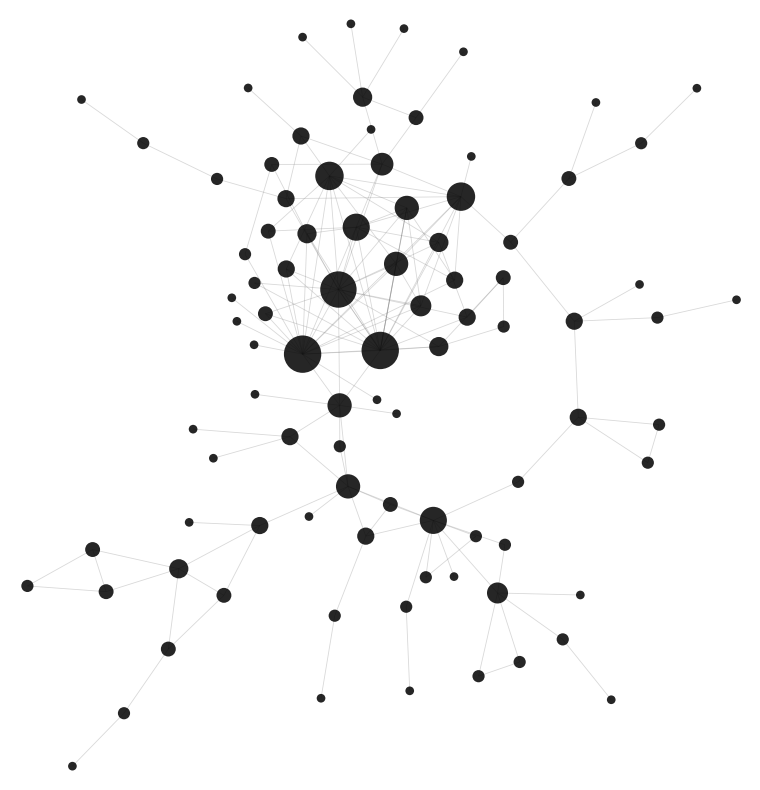

In [10]:
def declutter_positions(pos, node_sizes, ax, nodelist, padding_pts=2.0, outer_iters=5, inner_iters=200):
    """Nudge node centers apart (in data space) until the drawn marker circles
    (sized in points^2, matching nx.draw_networkx_nodes' node_size) stop
    overlapping, given the actual pixel scale of `ax`. Nudges are local pairwise
    repulsions, so the overall cluster layout from `pos` is preserved. Returns the
    new positions together with each node's final radius in data units (useful for
    setting axis limits that don't clip the markers)."""
    xs = np.array([pos[n][0] for n in nodelist], dtype=float)
    ys = np.array([pos[n][1] for n in nodelist], dtype=float)
    radii_pts = np.sqrt(np.array(node_sizes, dtype=float) / np.pi)
    radii_data = None

    for _ in range(outer_iters):
        margin = 0.15
        xr = max(xs.max() - xs.min(), 1e-6)
        yr = max(ys.max() - ys.min(), 1e-6)
        ax.set_xlim(xs.min() - margin * xr, xs.max() + margin * xr)
        ax.set_ylim(ys.min() - margin * yr, ys.max() + margin * yr)
        ax.figure.canvas.draw()

        p0 = ax.transData.transform((0, 0))
        p1 = ax.transData.transform((1, 0))
        pixels_per_data_unit = np.hypot(*(p1 - p0))
        pixels_per_point = ax.figure.dpi / 72.0
        radii_data = (radii_pts + padding_pts) * pixels_per_point / pixels_per_data_unit

        for _ in range(inner_iters):
            dx = xs[:, None] - xs[None, :]
            dy = ys[:, None] - ys[None, :]
            dist = np.hypot(dx, dy)
            np.fill_diagonal(dist, np.inf)
            min_dist = radii_data[:, None] + radii_data[None, :]
            overlap = np.maximum(min_dist - dist, 0)
            if not np.any(overlap > 1e-9):
                break
            safe_dist = np.where(np.isinf(dist), 1.0, dist)
            ux, uy = dx / safe_dist, dy / safe_dist
            xs += (ux * overlap).sum(axis=1) * 0.25
            ys += (uy * overlap).sum(axis=1) * 0.25

    return {n: (xs[i], ys[i]) for i, n in enumerate(nodelist)}, radii_data


def compute_cluster_layout(G, seed=42, community_padding=0.6):
    """Louvain communities, each internally laid out by its own spring layout,
    then packed against each other so they never spatially overlap: every
    community gets a bounding circle (radius = its own layout's extent from
    its centroid, plus `community_padding`), and those circles are pushed
    apart pairwise until none overlap -- the same push-apart-until-no-overlap
    idea as `declutter_positions`, just applied to whole communities instead
    of individual nodes. This is what makes clusters read as visually distinct
    islands instead of one dense hairball. Returns (pos, community_of,
    communities)."""
    communities = louvain_communities(G, seed=seed)
    community_of = {n: i for i, comm in enumerate(communities) for n in comm}

    # Rough initial ordering: communities that share more inter-community
    # edges start out closer together, before packing pushes them apart.
    comm_graph = nx.Graph()
    comm_graph.add_nodes_from(range(len(communities)))
    for u, v in G.edges():
        cu, cv = community_of[u], community_of[v]
        if cu != cv:
            w = comm_graph[cu][cv]["weight"] + 1 if comm_graph.has_edge(cu, cv) else 1
            comm_graph.add_edge(cu, cv, weight=w)
    macro_pos0 = nx.spring_layout(comm_graph, seed=seed, weight="weight", k=2.0)

    local_positions, radii = [], []
    for comm in communities:
        sub = G.subgraph(comm)
        local_scale = 0.3 + 0.15 * np.sqrt(len(comm))
        if len(comm) == 1:
            local_pos = {next(iter(comm)): np.zeros(2)}
        else:
            local_pos = nx.spring_layout(sub, seed=seed, scale=local_scale)
        local_positions.append(local_pos)
        pts = np.array(list(local_pos.values()))
        r = np.hypot(pts[:, 0], pts[:, 1]).max() if len(pts) > 1 else 0.05
        radii.append(r + community_padding)

    n_comm = len(communities)
    cx = np.array([macro_pos0[i][0] for i in range(n_comm)]) * 6.0
    cy = np.array([macro_pos0[i][1] for i in range(n_comm)]) * 6.0
    radii_arr = np.array(radii)
    for _ in range(1000):
        dx = cx[:, None] - cx[None, :]
        dy = cy[:, None] - cy[None, :]
        dist = np.hypot(dx, dy)
        np.fill_diagonal(dist, np.inf)
        min_dist = radii_arr[:, None] + radii_arr[None, :]
        overlap = np.maximum(min_dist - dist, 0)
        if not np.any(overlap > 1e-6):
            break
        safe_dist = np.where(np.isinf(dist), 1.0, dist)
        ux, uy = dx / safe_dist, dy / safe_dist
        cx += (ux * overlap).sum(axis=1) * 0.5
        cy += (uy * overlap).sum(axis=1) * 0.5

    pos = {}
    for i, comm in enumerate(communities):
        for n, (x, y) in local_positions[i].items():
            pos[n] = (cx[i] + x, cy[i] + y)
    return pos, community_of, communities


def visualize_network(G, ax, node_size_base=5, node_size_scale=50, reference_ax_area_in2=None,
                       use_cluster_layout=False, community_padding=0.6, shade_communities=True,
                       shade_color="0.95", color_by_community=False, seed=42):
    """Layout + overlap-free node sizes, drawn into `ax`. Works for any
    networkx graph. Returns the final positions and the panel's physical area
    in square inches (usable as `reference_ax_area_in2` for a later call).

    node_size is a physical (points^2) unit, so the same node_size_base/scale
    drawn into a smaller `ax` looks disproportionately crowded -- the markers
    take up a bigger fraction of the panel even though the layout itself is
    identical. Passing `reference_ax_area_in2` (the panel area this
    node_size_base/scale was calibrated for) rescales node sizes so the panel
    looks equally spacious regardless of how large `ax` physically is.

    By default this uses a single global kamada-kawai layout with black nodes
    (matching the PUD figures). Set `use_cluster_layout=True` to lay the graph
    out by non-overlapping Louvain communities instead (see
    `compute_cluster_layout`) -- this is what actually reveals cluster
    structure in denser graphs, where kamada-kawai (and even a
    community-influenced layout without packing) tends to collapse everything
    into one hairball. Inter-community edges are drawn much fainter than
    intra-community edges. `shade_communities` (only has an effect when
    `use_cluster_layout` is True) additionally gives each community a faint
    gray convex-hull background (color set by `shade_color`, a matplotlib
    grayscale string from "0" black to "1" white) so clusters stay legible in
    monochrome, without needing color -- set it to False to turn the
    background off and keep just the layout/edge-fading cues. `color_by_community`
    additionally colors nodes by community (only has an effect when
    `use_cluster_layout` is True); otherwise nodes stay black.
    """
    fig = ax.figure
    fig.canvas.draw()
    bbox = ax.get_window_extent()
    ax_area_in2 = (bbox.width / fig.dpi) * (bbox.height / fig.dpi)
    if reference_ax_area_in2 is not None:
        area_scale = ax_area_in2 / reference_ax_area_in2
        node_size_base = node_size_base * area_scale
        node_size_scale = node_size_scale * area_scale

    Gu = G.to_undirected()
    if use_cluster_layout:
        pos, community_of, communities = compute_cluster_layout(Gu, seed=seed, community_padding=community_padding)
    else:
        pos = nx.kamada_kawai_layout(Gu)
        community_of, communities = None, None

    degrees = dict(G.degree())
    node_sizes = [node_size_base + degrees[n] * node_size_scale for n in G.nodes()]
    nodelist = list(G.nodes())

    ax.set_aspect("equal", adjustable="box")
    pos, radii_data = declutter_positions(pos, node_sizes, ax, nodelist)

    if communities is not None and shade_communities:
        for comm in communities:
            pts = np.array([pos[n] for n in comm])
            if len(pts) < 3:
                continue
            hull = ConvexHull(pts)
            poly = pts[hull.vertices]
            centroid = poly.mean(axis=0)
            poly = centroid + (poly - centroid) * 1.25  # pad so markers don't poke out
            ax.add_patch(mpatches.Polygon(poly, closed=True, facecolor=shade_color, edgecolor="none", zorder=0))

    if community_of is not None:
        intra_edges = [(u, v) for u, v in G.edges() if community_of[u] == community_of[v]]
        inter_edges = [(u, v) for u, v in G.edges() if community_of[u] != community_of[v]]
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=inter_edges, edge_color="gray", alpha=0.05, width=0.5, arrows=False)
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=intra_edges, edge_color="gray", alpha=0.4, width=0.6, arrows=False)
    else:
        nx.draw_networkx_edges(
            G, pos, ax=ax, edge_color="gray", alpha=0.3, width=0.6, arrows=False
        )

    if color_by_community and community_of is not None:
        cmap = plt.get_cmap("tab20", len(communities))
        node_color = [cmap(community_of[n]) for n in nodelist]
    else:
        node_color = "black"

    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        nodelist=nodelist,
        node_size=node_sizes,
        node_color=node_color,
        alpha=0.85,
        linewidths=0,
    )

    xs_final = np.array([pos[n][0] for n in nodelist])
    ys_final = np.array([pos[n][1] for n in nodelist])
    pad = radii_data * 1.15
    ax.set_xlim((xs_final - pad).min(), (xs_final + pad).max())
    ax.set_ylim((ys_final - pad).min(), (ys_final + pad).max())
    ax.axis("off")
    return pos, ax_area_in2


# Calibrate the PUD node-size scale so its largest (max-degree) node is exactly
# twice the diameter -- i.e. 4x the area, since node_size is an area -- of a
# node in the complete (K10) network, which uses base=5, scale=50 (see the
# simple-networks cell below).
_simple_base, _simple_scale = 1, 20
_complete_ref_size = _simple_base + (10 - 1) * _simple_scale  # every K10 node has degree 9

_pud_max_degree = max(dict(pud_network.degree()).values())
_pud_node_size_scale = (4 * _complete_ref_size - _simple_base) / _pud_max_degree

fig, ax = plt.subplots(figsize=(10, 8))
_, _pud_reference_ax_area = visualize_network(pud_network, ax, node_size_base=_simple_base, node_size_scale=_pud_node_size_scale)
plt.tight_layout()
plt.savefig("results/pud_network_black.png", dpi=300, bbox_inches="tight")
plt.show()

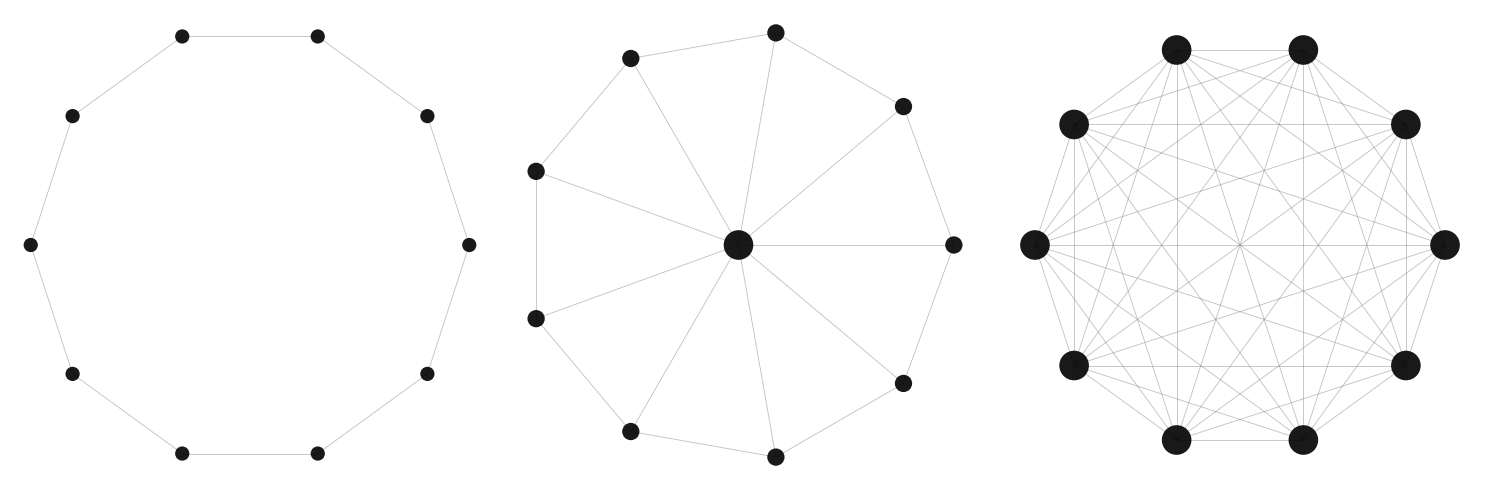

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

networks = {
    "Cycle": nx.cycle_graph(10),
    "Wheel": nx.wheel_graph(10),
    "Complete": nx.complete_graph(10),
}

for ax, (title, Gn) in zip(axes, networks.items()):
    if title == "Wheel":
        hub = 0
        pos = nx.circular_layout(Gn.subgraph([n for n in Gn if n != hub]))
        pos[hub] = (0.0, 0.0)
    else:
        pos = nx.circular_layout(Gn)

    ax.set_aspect("equal", adjustable="box")
    degrees = dict(Gn.degree())
    nodelist = list(Gn.nodes())
    node_sizes = [5 + degrees[n] * 50 for n in nodelist]
    pos, radii_data = declutter_positions(pos, node_sizes, ax, nodelist)

    nx.draw_networkx_edges(Gn, pos, ax=ax, edge_color="gray", alpha=0.5, width=0.6)
    nx.draw_networkx_nodes(
        Gn, pos, ax=ax, nodelist=nodelist, node_size=node_sizes,
        node_color="black", alpha=0.9, linewidths=0,
    )

    xs_final = np.array([pos[n][0] for n in nodelist])
    ys_final = np.array([pos[n][1] for n in nodelist])
    pad = radii_data * 1.15
    ax.set_xlim((xs_final - pad).min(), (xs_final + pad).max())
    ax.set_ylim((ys_final - pad).min(), (ys_final + pad).max())
    ax.axis("off")

plt.tight_layout()
plt.savefig("results/simple_networks_circular.png", dpi=300, bbox_inches="tight")
plt.show()

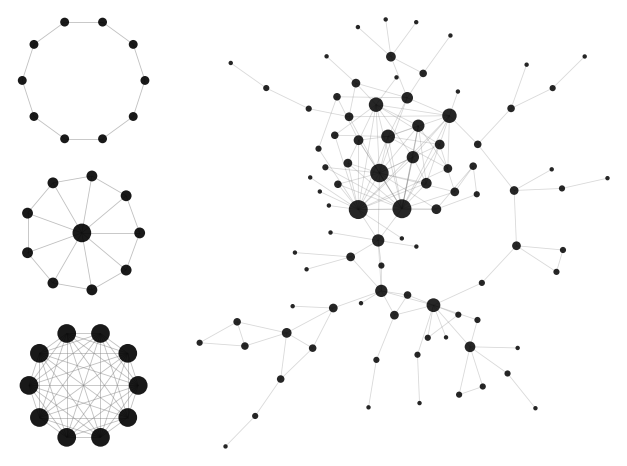

In [23]:
page_width = 8.27
margin = 1.0
total_width = page_width - 2 * margin
gap = 0.2

r_pud_guess = 1.0  # kamada-kawai layouts of this graph render close to square
left_w = (total_width - gap) / (1 + 3 * r_pud_guess)
right_w = total_width - gap - left_w
fig_height = 3 * left_w

fig = plt.figure(figsize=(total_width, fig_height))
gs = fig.add_gridspec(3, 2, width_ratios=[left_w, right_w], wspace=0.08, hspace=0.08)

for i, (title, Gn) in enumerate(networks.items()):
    ax = fig.add_subplot(gs[i, 0])
    if title == "Wheel":
        hub = 0
        pos = nx.circular_layout(Gn.subgraph([n for n in Gn if n != hub]))
        pos[hub] = (0.0, 0.0)
    else:
        pos = nx.circular_layout(Gn)

    ax.set_aspect("equal", adjustable="box")
    degrees = dict(Gn.degree())
    nodelist = list(Gn.nodes())
    node_sizes = [_simple_base + degrees[n] * _simple_scale for n in nodelist]
    pos, radii_data = declutter_positions(pos, node_sizes, ax, nodelist)

    nx.draw_networkx_edges(Gn, pos, ax=ax, edge_color="gray", alpha=0.5, width=0.6)
    nx.draw_networkx_nodes(
        Gn, pos, ax=ax, nodelist=nodelist, node_size=node_sizes,
        node_color="black", alpha=0.9, linewidths=0,
    )

    xs_final = np.array([pos[n][0] for n in nodelist])
    ys_final = np.array([pos[n][1] for n in nodelist])
    pad = radii_data * 1.15
    ax.set_xlim((xs_final - pad).min(), (xs_final + pad).max())
    ax.set_ylim((ys_final - pad).min(), (ys_final + pad).max())
    ax.axis("off")

ax_pud = fig.add_subplot(gs[:, 1])
visualize_network(
    pud_network, ax_pud, node_size_base=_simple_base, node_size_scale=_pud_node_size_scale,
    reference_ax_area_in2=_pud_reference_ax_area,
)

fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01, wspace=0.08, hspace=0.08)
plt.savefig("results/simple_and_pud_networks.png", dpi=300)
save_figure_in_paper_fig_dir("simple_and_pud_networks.png", dpi=300)
plt.show()

## Tobacco network and variant network

In [13]:
from networks.variation_methods import generate_equalize_variant

/Users/heinduijf/GitHub/e_network_inequality/e_network_inequality/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
with open("networks/citation_data/tobacco_network.pkl", "rb") as f:
    tobacco_network = pickle.load(f)

print(f"Nodes: {tobacco_network.number_of_nodes()}, Edges: {tobacco_network.number_of_edges()}")

Nodes: 289, Edges: 1229


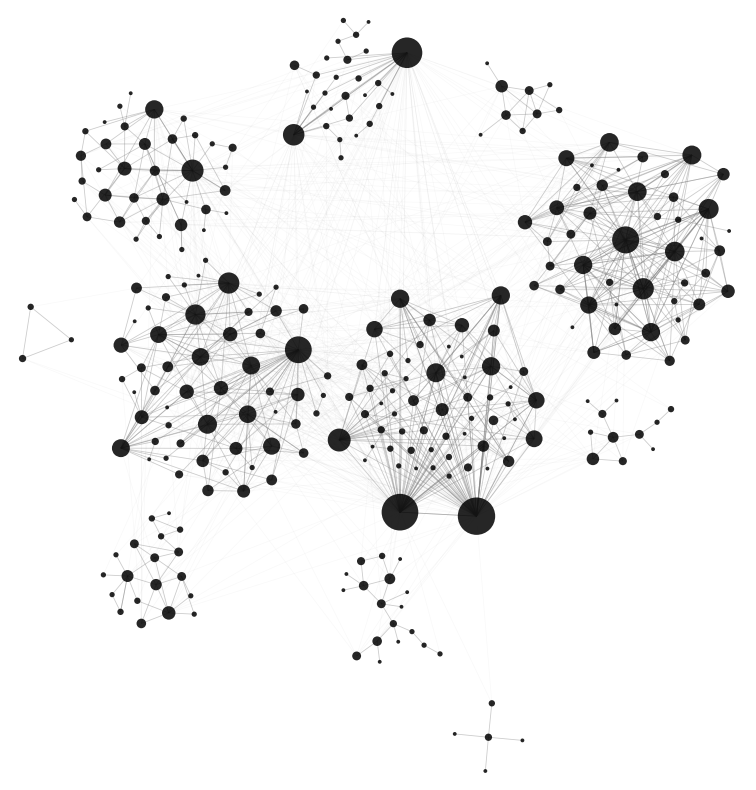

In [22]:
_tobacco_max_degree = max(dict(tobacco_network.degree()).values())
_tobacco_node_size_scale = (4 * _complete_ref_size - _simple_base) / _tobacco_max_degree

fig, ax = plt.subplots(figsize=(10, 8))
_, _tobacco_reference_ax_area = visualize_network(
    tobacco_network, ax, node_size_base=_simple_base, node_size_scale=_tobacco_node_size_scale,
    use_cluster_layout=True, shade_communities=False,
)
plt.tight_layout()
plt.savefig("results/tobacco_network_black.png", dpi=300, bbox_inches="tight")
save_figure_in_paper_fig_dir("tobacco_network_black.png", dpi=300, bbox_inches="tight")
plt.show()


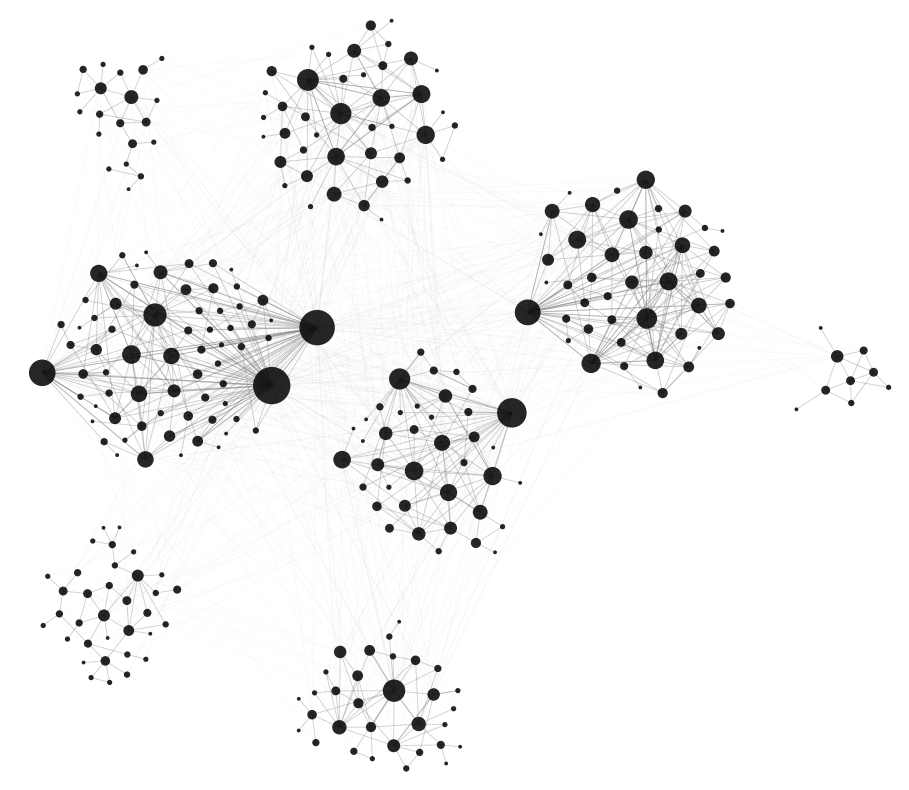

In [28]:
tobacco_variant, _, _ = generate_equalize_variant(
    tobacco_network, 
    n_edges=int(0.1 * tobacco_network.number_of_edges()),
)
_variant_max_degree = max(dict(tobacco_variant.degree()).values())
_variant_node_size_scale = (4 * _complete_ref_size - _simple_base) / _variant_max_degree

fig, ax = plt.subplots(figsize=(10, 8))
_, _variant_reference_ax_area = visualize_network(
    tobacco_variant, ax, node_size_base=_simple_base, node_size_scale=_variant_node_size_scale,
    use_cluster_layout=True, shade_communities=False,
)
plt.tight_layout()
plt.savefig("results/tobacco_variant_network_black.png", dpi=300, bbox_inches="tight")
save_figure_in_paper_fig_dir("tobacco_variant_network_black.png", dpi=300, bbox_inches="tight")
plt.show()


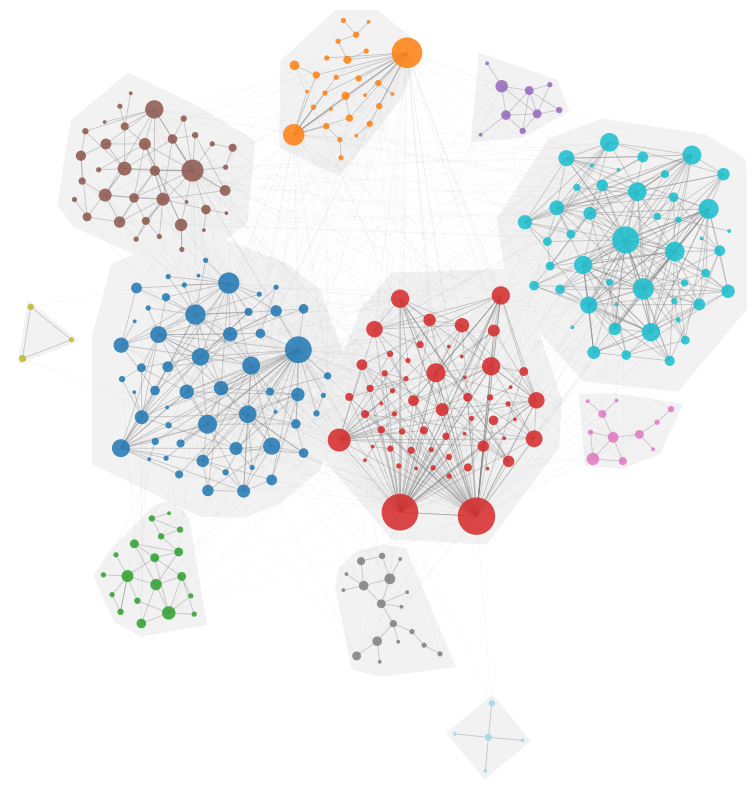

In [17]:
# Same cluster layout, but colored by community -- optional alternative to the
# black version above, for when cluster identity needs to be unambiguous
# (e.g. talks/exploration) rather than matching the black print style.
fig, ax = plt.subplots(figsize=(10, 8))
visualize_network(
    tobacco_network, ax, node_size_base=_simple_base, node_size_scale=_tobacco_node_size_scale,
    use_cluster_layout=True, shade_communities=True, color_by_community=True,
)
plt.tight_layout()
plt.savefig("results/tobacco_network_clusters_colored.png", dpi=300, bbox_inches="tight")
plt.show()


# Influence

## Setup

In [18]:
import pandas as pd
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [19]:
with open("networks/citation_data/pud_network.pkl", "rb") as f:
    pud_network = pd.read_pickle(f)

with open("networks/citation_data/tobacco_network.pkl", "rb") as f:
    tobacco_network = pd.read_pickle(f)

with open("networks/citation_data/ego_network.pkl", "rb") as f:
    ego_network = pd.read_pickle(f)

In [20]:
def influence_plot(
    network: nx.DiGraph,
):
    in_degrees = dict(network.in_degree())
    out_degrees = dict(network.out_degree())
    fig = sns.scatterplot(
        x=list(in_degrees.values()),
        y=list(out_degrees.values()),
        color="black",
        alpha=0.7,
    )
    fig.yaxis.set_major_locator(MaxNLocator(integer=True))
    fig.set_ylim(bottom=0)
    fig.set_xlim(left=0)
    fig.set_xlabel("In-Degree")
    fig.set_ylabel("Out-Degree")
    plt.show()

## Plots

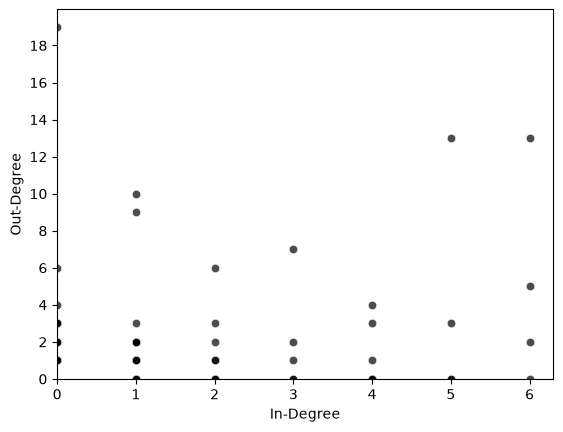

In [7]:
influence_plot(pud_network)

In [8]:
network = pud_network
in_degrees = network.in_degree()
len([agent for agent, in_degree in in_degrees if in_degree == 0]) / network.number_of_nodes()

0.23333333333333334

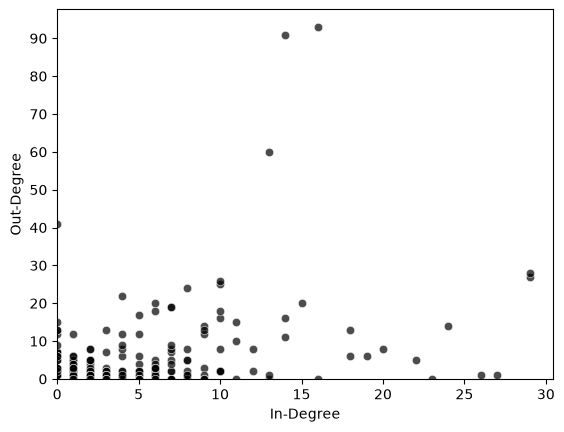

In [9]:
influence_plot(tobacco_network)

In [10]:
network = tobacco_network

In [11]:
in_degrees = dict(tobacco_network.in_degree())
influential_agents = sorted(
    dict(tobacco_network.out_degree()).items(), key=lambda x: x[1], reverse=True
)[:5]

data = [
    (out_degree, in_degrees[agent]) for agent, out_degree in influential_agents
]
data


[(93, 16), (91, 14), (60, 13), (41, 0), (28, 29)]

In [12]:
in_degrees = network.in_degree()
len([agent for agent, in_degree in in_degrees if in_degree == 0]) / network.number_of_nodes()

0.18339100346020762

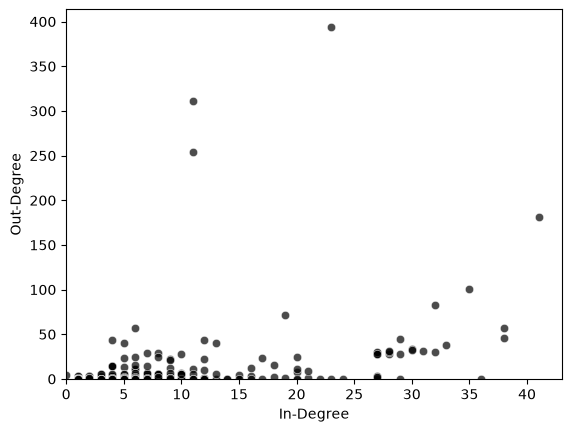

In [13]:
influence_plot(ego_network)

In [14]:
in_degrees = dict(ego_network.in_degree())
influential_agents = sorted(
    dict(ego_network.out_degree()).items(), key=lambda x: x[1], reverse=True
)[:5]

data = [
    (out_degree, in_degrees[agent]) for agent, out_degree in influential_agents
]
data

[(394, 23), (311, 11), (254, 11), (181, 41), (101, 35)]

In [15]:
network = ego_network
in_degrees = network.in_degree()
len([agent for agent, in_degree in in_degrees if in_degree == 0]) / network.number_of_nodes()

0.0019880715705765406

## Analysis

In [16]:
from scipy.stats import binom

for n_agents in [7, 17, 24]:
    print(f"{100*binom.cdf(1000*n_agents/2 - 1, 1000*n_agents, 0.501):.0f}")


43
39
38


Calculate clustering for simple networks?